In [ ]:
import labrad
from labrad import units
import numpy as np
import matplotlib.pyplot as plt
from os import path
import sys
import imageio
import scipy.optimize as opt
from scipy.optimize import curve_fit
from scipy import signal
from pylablib.devices import Thorlabs
from PIL import Image
import time
# 


import datetime
from pathlib import Path
import imutils

_root = path.abspath(path.join(
    '//arqusws-01', 'ArQuS Shared', 'LabRAD', 'LabRADCodes', 'servers', 'Spectrum_Card'))
sys.path.append(_root)


# import wavegen as wg

#connecting to labrad
cxn = labrad.connect('192.168.1.21', password='ytterbium171')
PM = cxn.picomotors

In [ ]:
PM.get_id()

In [ ]:
# import pylablib as pll
# pll.par["devices/dlls/thorlabs_tlcam"] = "C:/Program Files/Thorlabs/Scientific Imaging/ThorCam"
Thorlabs.list_cameras_tlcam()

In [ ]:
MHz = 1e6
Mako_G_234_B = False
Mako_G_158_B = False
Thor_Cam = True

THEORETICAL = False
EXP = True

if EXP == True:
    MAGNIFICATION = 34.2
    # MAGNIFICATION = 78
elif THEORETICAL == True:
    MAGNIFICATION = 300/9
    MAGNIFICATION = 300/4

TWEEZERS_NUMBER = 1

#define the grid of pixels
if Mako_G_234_B == True:
    PX = 5.86
if Thor_Cam or Mako_G_158_B == True:
    PX = 3.45

In [ ]:
# SC = cxn.m4i_6621_x8
# PM = cxn.picomotors

if Thor_Cam == True:
    cam = Thorlabs.ThorlabsTLCamera(serial='13286')
    cam.set_exposure(0.064*1e-3) # in seconds
    px = 3.45
    
elif Mako_G_234_B or Mako_G_158_B == True:
    #set exposure time
    MC = cxn.mako_camera
    print(MC.exposure_time(16 * units.us))
    print(MC.pixel_format('Mono8'))
    print(MC.gain(0 * units.dB))
    print(MC.frame_size(1936, 1216))
    px = 5.86


In [ ]:
#define fitting functions
def gaussian_2D(xdata_tuple, amp, x0, y0, sigma_x, sigma_y):
    (x, y) = xdata_tuple
    G = amp * np.exp(-2 * ((x - x0) ** 2 / sigma_x ** 2 + (y - y0) ** 2 / sigma_y ** 2))
    return G.ravel()

def sum_of_2D_gaussians(xdata_tuple, *params):
    n = len(params) // 5  # Each Gaussian has 5 parameters: amp, x0, y0, sigma_x, sigma_y
    G = 0
    for i in range(n):
        amp, x0, y0, sigma_x, sigma_y = params[i * 5: ((i + 1) * 5)]
        G += gaussian_2D(xdata_tuple, amp, x0, y0, sigma_x, sigma_y)
    return G.ravel()

In [ ]:
PM.set_position_reference(1, 0)
PM.get_position('all')



###########################
step number: 1
###########################




Acquring image...




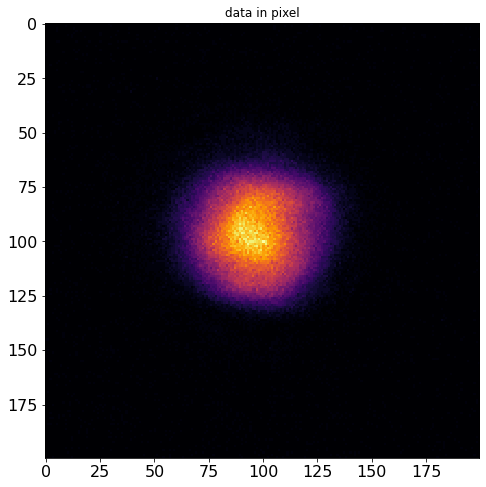

atom size in x direction: 3874.088 nm
atom size in y direction: 3875.197 nm


###########################
step number: 2
###########################




Acquring image...




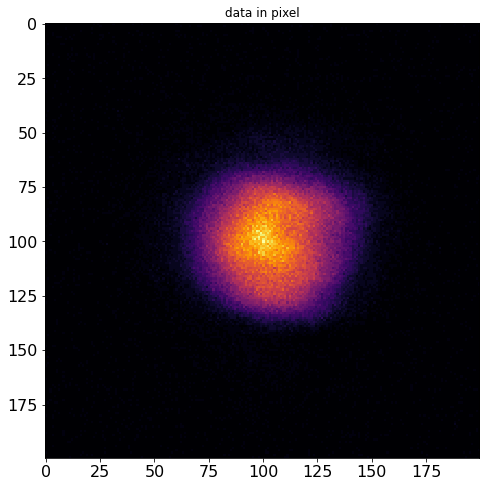

atom size in x direction: 4468.154 nm
atom size in y direction: 4345.285 nm


###########################
step number: 3
###########################




Acquring image...




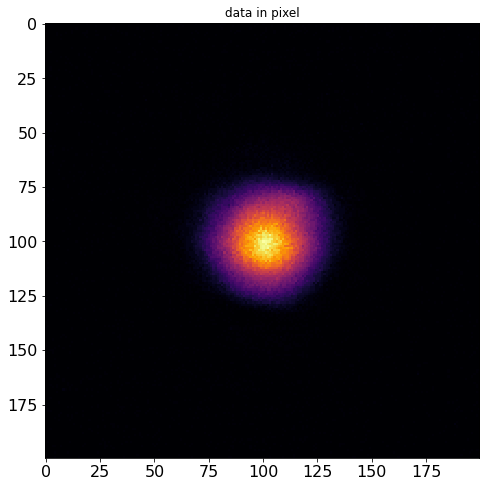

atom size in x direction: 3006.645 nm
atom size in y direction: 2882.061 nm


###########################
step number: 4
###########################




Acquring image...




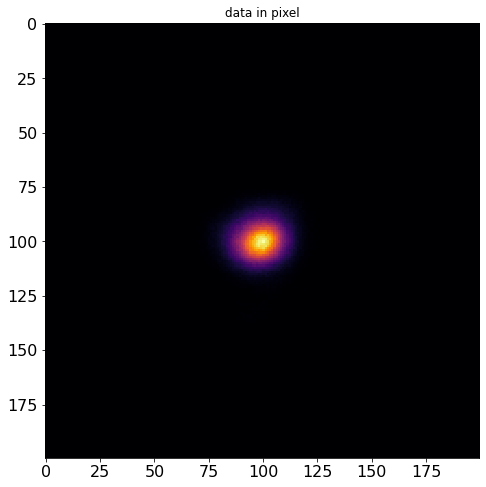

atom size in x direction: 1605.864 nm
atom size in y direction: 1400.579 nm


###########################
step number: 5
###########################




Acquring image...




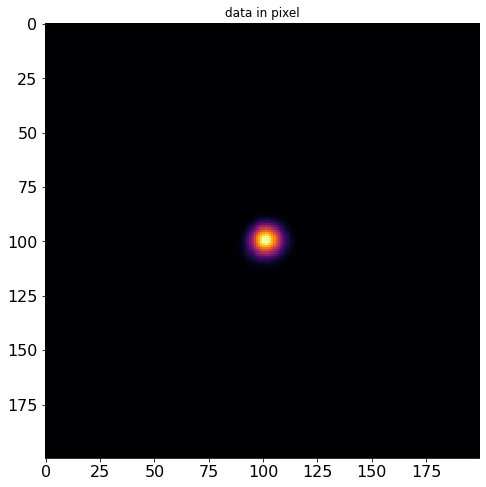

atom size in x direction: 968.623 nm
atom size in y direction: 938.561 nm


###########################
step number: 6
###########################




Acquring image...




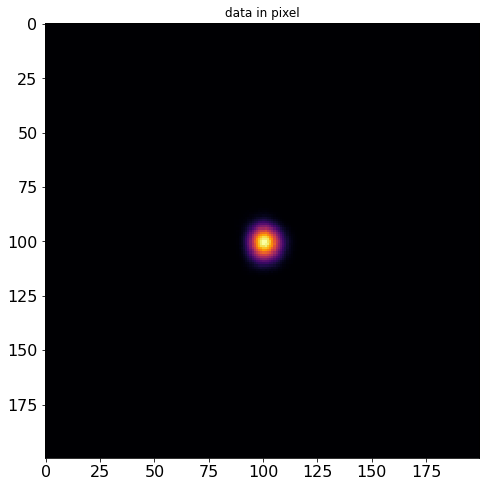

atom size in x direction: 945.522 nm
atom size in y direction: 1038.127 nm


###########################
step number: 7
###########################




Acquring image...




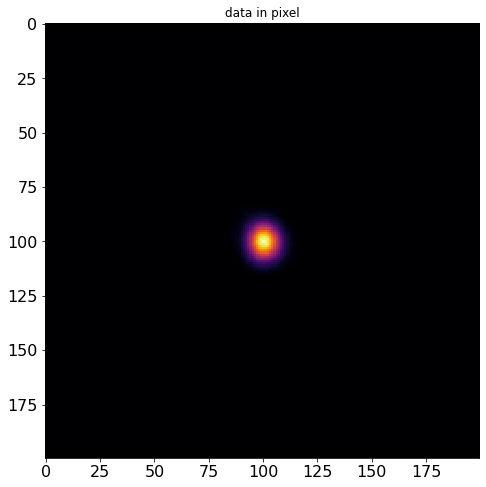

atom size in x direction: 997.272 nm
atom size in y direction: 1134.263 nm


In [124]:
GAUSSIAN_FIT = True

x_waist = []
y_waist = []


index = 0
while True:

    print('\n')
    print('###########################')
    print(f'step number: {index+1}')
    print('###########################')
    print('\n')

    cam.set_exposure(0.064*10**-3) # in seconds
    

    # creates the path for the image and acquires it
    file_name = datetime.datetime.now()
    file_name = "%s.%s.%s.%s.%s.%s" % (file_name.year, file_name.month, file_name.day, file_name.hour, file_name.minute, file_name.second)
    file_name = file_name + f'_special_optics_80MHz_single_tone_step={index}'
    __path__ = "//ARQUS-NAS/ArQuS Shared/Characterizations/Tweezers Analysis/real_setup/special_optics_tweezers/"
    fullpath = __path__ + str(file_name)

    print('\n')
    print('Acquring image...')
    print('\n')


    if Mako_G_158_B or Mako_G_234_B == True:
        MC.frame_grab(fullpath, 'tif')
        img = imageio.imread(fullpath + '.tif')
        img = img[:, ::-1] #mirrors the image left right
        img = imutils.rotate(img, angle=2.15)
        img = img[300:700, 1040:1900]

    elif Thor_Cam == True:
        img = cam.snap()
        # img_save = Image.fromarray(img)
        # img_save.save(fullpath + '.tif')
        # img = img[:, ::-1] #mirrors the image left right
        # img = imutils.rotate(img, angle=-0.1)
        x_max = int(np.mean(np.where(img == img.max())[1]))
        y_max = int(np.mean(np.where(img == img.max())[0]))
        img = img[y_max-100:y_max+100, x_max-100:x_max+100]

        # defines the grid of pixels
        rows = img.shape[0]
        cols = img.shape[1]
        x = np.arange(cols)
        y = np.arange(rows)
        x, y = np.meshgrid(x, y)
    
        # # plot the raw image
        fig, (ax1) = plt.subplots(1, figsize=(20, 8))
        ax1.imshow(img, interpolation='nearest', cmap='inferno')

        ax1.xaxis.set_tick_params(labelsize=16)
        ax1.yaxis.set_tick_params(labelsize=16)
        ax1.set_title('data in pixel')
        plt.show()


    if GAUSSIAN_FIT == True:
        # guessed parameters for the gaussians to fit
        amp = 120
        y0 = 60
        x0 = 0
        sigma_x = 5
        sigma_y = 5

        params = [amp, x0, y0, sigma_x, sigma_y] * TWEEZERS_NUMBER

        # # finds automatically the peaks
        peaks, _ = signal.find_peaks(img[y0, :], height = 40, distance = 20)

        # # build the x0 params with results found from the find_peaks function
        # for i in range(int(len(params)/5)):
        #     params[1+(i*5)] = peaks[i]
        

        # # init_guess = np.array(init_guess, dtype='float64')
        p_opt, cov = opt.curve_fit(sum_of_2D_gaussians, (x, y), img.ravel(), p0 = params)
        err = np.sqrt(np.diag(cov))
        
        amp = []
        x0 = []
        y0 = []
        sigma_x = []
        sigma_y = []

        for i in range(TWEEZERS_NUMBER):
            amp.append(p_opt[0+(i*5)])
        amp = [round(i, 3) for i in amp]

        for i in range(TWEEZERS_NUMBER):
            x0.append(p_opt[1+(i*5)])
        x0 = [round(i, 3) for i in x0]

        for i in range(TWEEZERS_NUMBER):
            y0.append(p_opt[2+(i*5)])
        y0 = [round(i, 3) for i in y0]

        for i in range(TWEEZERS_NUMBER):
            sigma_x.append(p_opt[3+(i*5)])
        sigma_x = [round(i, 3) for i in sigma_x]

        for i in range(TWEEZERS_NUMBER):
            sigma_y.append(p_opt[4+(i*5)])
        sigma_y = [round(i, 3) for i in sigma_y]


        # print(f'amplitude list: {amp}')
        # print(f'x0 list: {x0}')
        # print(f'y0 list {y0}')
        # print(f'sigma x list: {sigma_x}')
        # print(f'sigma y list: {sigma_y}')


        average_x_size = 0
        for i in range(TWEEZERS_NUMBER):
            x_size = np.abs(round(1e3*sigma_x[i]*PX/MAGNIFICATION, 3))
            average_x_size += x_size
            print(f'atom size in x direction: {x_size} nm')
        average_x_size = round(average_x_size/TWEEZERS_NUMBER, 2)

        average_y_size = 0
        for i in range(TWEEZERS_NUMBER):
            y_size = np.abs(round(1e3*sigma_y[i]*PX/MAGNIFICATION, 3))
            average_y_size += y_size
            print(f'atom size in y direction: {y_size} nm')
        average_y_size = round(average_y_size/TWEEZERS_NUMBER, 3)


        if x_waist != []:
            x_waist.append(x_size)
            if x_waist[1] > x_waist[0]:
                    PM.relative_move(1, -120)
            elif x_waist[1] < x_waist[0]:
                PM.relative_move(1, +120)
                    

        elif x_waist == []:
            x_waist.append(x_size)
            PM.relative_move(1, +80)




        if len(x_waist) >= 3:
            if x_waist[-2] < x_waist[-1] and x_waist[-2] < x_waist[-3]:
                if x_waist[1] > x_waist[0]:
                    PM.relative_move(1, +100)
                elif x_waist[1] < x_waist[0]:
                    PM.relative_move(1, -100)
                break
        
    index+=1


         



In [123]:
PM.relative_move(1, +100)